
Cluster Profile (Mean Values):
               Age  Annual_Income_(k$)  Spending_Score
Cluster                                               
0        46.250000           26.750000       18.350000
1        25.185185           41.092593       62.240741
2        32.875000           86.100000       81.525000
3        39.871795           86.102564       19.358974
4        55.638298           54.382979       48.851064


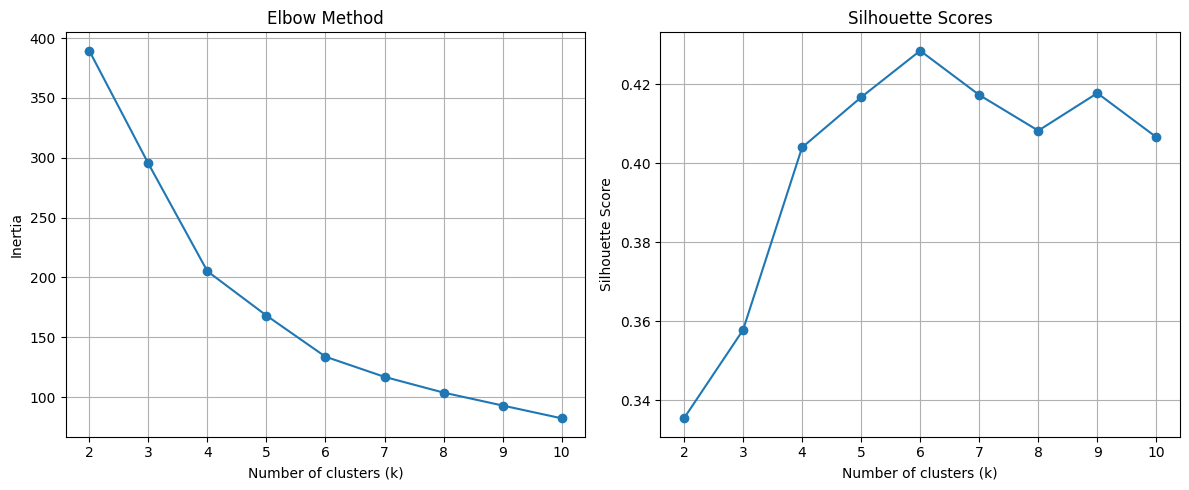

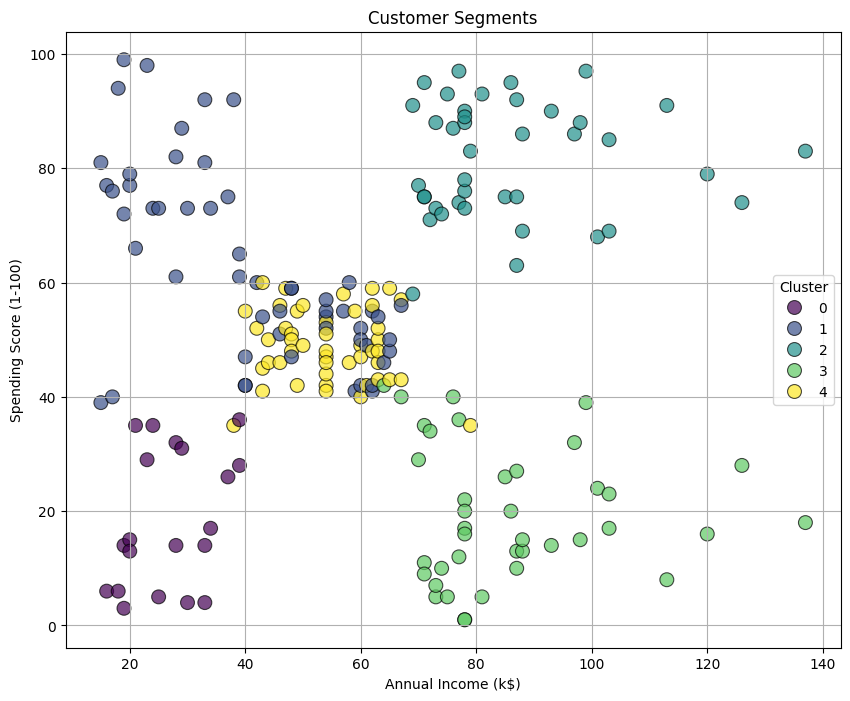

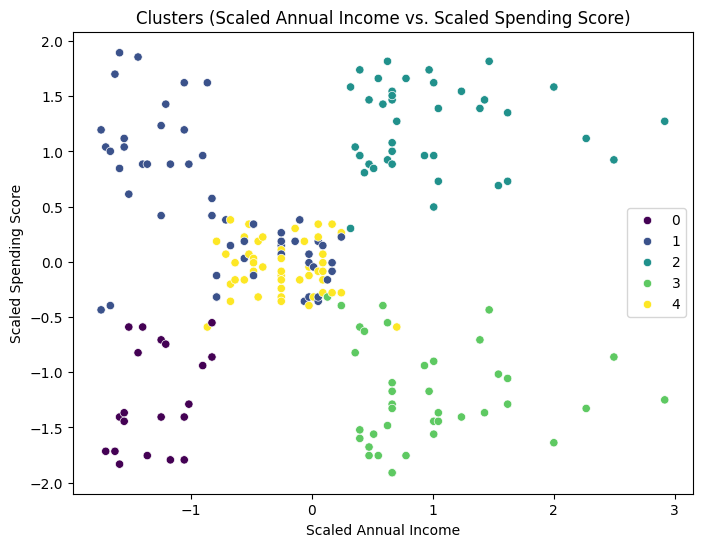

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import silhouette_score 
 
# 1. Load the data 
# Make sure to upload "Mall_Customers.csv" 
df = pd.read_csv("bida-2.csv") 
 
# 2. Select features for clustering 
# Corrected column names to match the CSV file 
X = df[['Age', 'Annual_Income_(k$)', 'Spending_Score']].copy() 
 
# 3. Scale the features
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 

# 4. Determine optimal K 
inertias = [] 
sil_scores = [] 
K_range = range(2, 11) 
for k in K_range: 
    model = KMeans(n_clusters=k, random_state=42, n_init=10) 
    labels = model.fit_predict(X_scaled) 
    inertias.append(model.inertia_) 
    sil = silhouette_score(X_scaled, labels) 
    sil_scores.append(sil) 

# Plot elbow and silhouette scores 
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
plt.plot(K_range, inertias, marker='o') 
plt.xlabel('Number of clusters (k)') 
plt.ylabel('Inertia') 
plt.title('Elbow Method') 
plt.grid(True) 
plt.subplot(1, 2, 2) 
plt.plot(K_range, sil_scores, marker='o') 
plt.xlabel('Number of clusters (k)') 
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Scores') 
plt.grid(True) 
plt.tight_layout() 
plt.savefig("elbow_silhouette.png") 

# 5. Fit final KMeans with your chosen k 
best_k = 5 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10) 
clusters = kmeans.fit_predict(X_scaled) 
# Add clusters back to original DataFrame 
df['Cluster'] = clusters 

# 6. Analyze clusters 
cluster_profile = df.groupby('Cluster')[['Age', 'Annual_Income_(k$)', 
'Spending_Score']].mean() 
print("\nCluster Profile (Mean Values):") 
print(cluster_profile) 

# 7. Visualize clusters 
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df['Annual_Income_(k$)'], y=df['Spending_Score'], hue=df['Cluster'], 
palette='viridis', s=100, alpha=0.7, edgecolor='k') 
plt.title('Customer Segments') 
plt.xlabel('Annual Income (k$)') 
plt.ylabel('Spending Score (1-100)') 
plt.legend(title='Cluster') 
plt.grid(True) 
plt.savefig("cluster_scatterplot.png") n
# Also visualize with scaled data 
plt.figure(figsize=(8,6)) 
sns.scatterplot(x=X_scaled[:,1], y=X_scaled[:,2], hue=clusters, palette='viridis', legend='full') 
plt.title('Clusters (Scaled Annual Income vs. Scaled Spending Score)') 
plt.xlabel('Scaled Annual Income') 
plt.ylabel('Scaled Spending Score') 
plt.savefig("clusters_scaled.png")